In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12,6)

matches = pd.read_csv("../data/processed/matches_cleaned.csv")
deliveries = pd.read_excel("../data/raw/deliveries.xlsx")

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


In [2]:
head_to_head = (
    matches.groupby(["team1", "team2", "winner"])
    .size()
    .reset_index(name="Wins")
)

display(head_to_head.head(20))

,team1,team2,winner,Wins
0,Chennai Super Kings,Deccan Chargers,Chennai Super Kings,4
1,Chennai Super Kings,Deccan Chargers,Deccan Chargers,3
2,Chennai Super Kings,Delhi Capitals,Chennai Super Kings,11
3,Chennai Super Kings,Delhi Capitals,Delhi Capitals,6
4,Chennai Super Kings,Gujarat Titans,Chennai Super Kings,2
5,Chennai Super Kings,Gujarat Titans,Gujarat Titans,3
6,Chennai Super Kings,Kochi Tuskers Kerala,Chennai Super Kings,1
7,Chennai Super Kings,Kolkata Knight Riders,Chennai Super Kings,9
8,Chennai Super Kings,Kolkata Knight Riders,Kolkata Knight Riders,5
9,Chennai Super Kings,Lucknow Super Giants,Chennai Super Kings,1


In [3]:
teamA = "Mumbai Indians"
teamB = "Chennai Super Kings"

h2h = matches[
    (
        ((matches["team1"] == teamA) & (matches["team2"] == teamB))
        |
        ((matches["team1"] == teamB) & (matches["team2"] == teamA))
    )
]

display(h2h[["season","winner","venue"]])

,season,winner,venue
7,2007/08,Chennai Super Kings,"MA Chidambaram Stadium, Chepauk"
35,2007/08,Mumbai Indians,Wankhede Stadium
58,2009,Mumbai Indians,Newlands
102,2009,Chennai Super Kings,St George's Park
134,2009/10,Mumbai Indians,"Brabourne Stadium, Mumbai"
151,2009/10,Chennai Super Kings,"MA Chidambaram Stadium, Chepauk"
174,2009/10,Chennai Super Kings,Dr DY Patil Sports Academy
197,2011,Mumbai Indians,Wankhede Stadium
248,2012,Mumbai Indians,"MA Chidambaram Stadium, Chepauk"
294,2012,Mumbai Indians,Wankhede Stadium


In [4]:
matches["Bat_First_Won"] = (
    matches["result"] == "runs"
)

strategy = (
    matches["Bat_First_Won"]
    .value_counts()
    .reset_index()
)

strategy.columns=["Bat First Won","Matches"]

display(strategy)

,Bat First Won,Matches
0,False,597
1,True,498


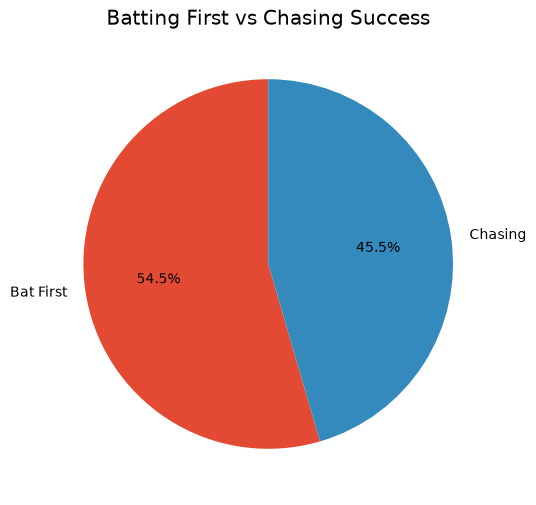

In [5]:
plt.pie(
    strategy["Matches"],
    labels=["Bat First","Chasing"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Batting First vs Chasing Success")

plt.show()

In [6]:
orange_cap = (
    deliveries.groupby("batter")["batsman_runs"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

orange_cap.columns=["Player","Runs"]

display(orange_cap.head(20))

,Player,Runs
0,V Kohli,8014
1,S Dhawan,6769
2,RG Sharma,6630
3,DA Warner,6567
4,SK Raina,5536
5,MS Dhoni,5243
6,AB de Villiers,5181
7,CH Gayle,4997
8,RV Uthappa,4954
9,KD Karthik,4843


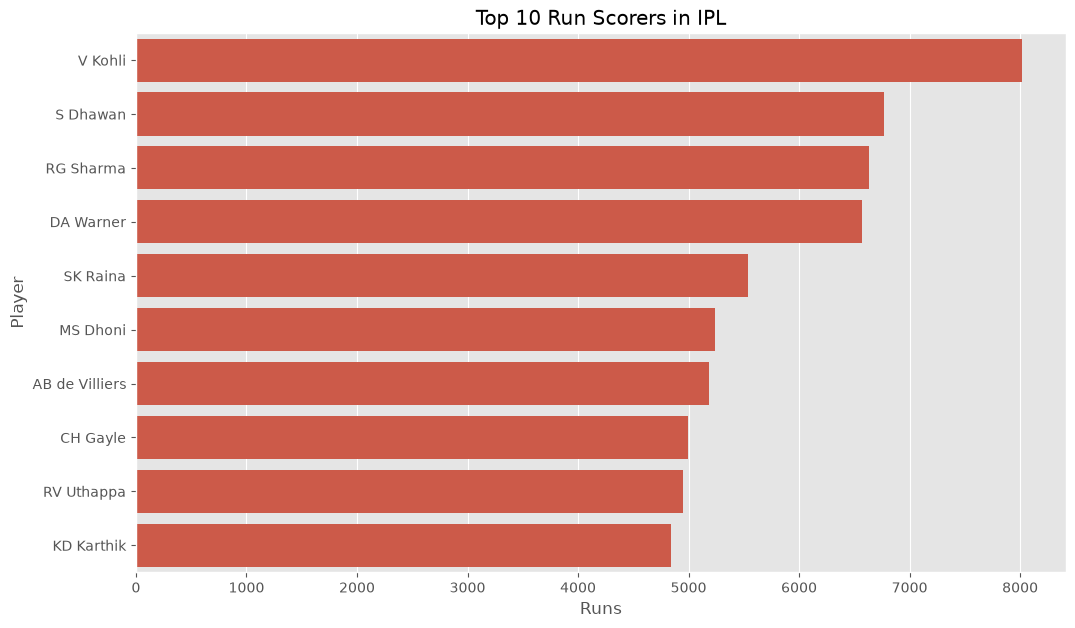

In [7]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=orange_cap.head(10),
    x="Runs",
    y="Player"
)

plt.title("Top 10 Run Scorers in IPL")

plt.show()

In [8]:
wickets = deliveries[
    deliveries["dismissal_kind"].notna()
]

purple_cap = (
    wickets.groupby("bowler")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="Wickets")
)

display(purple_cap.head(20))

,bowler,Wickets
0,YS Chahal,213
1,DJ Bravo,207
2,PP Chawla,201
3,SP Narine,200
4,R Ashwin,198
5,B Kumar,195
6,SL Malinga,188
7,A Mishra,183
8,JJ Bumrah,182
9,RA Jadeja,169


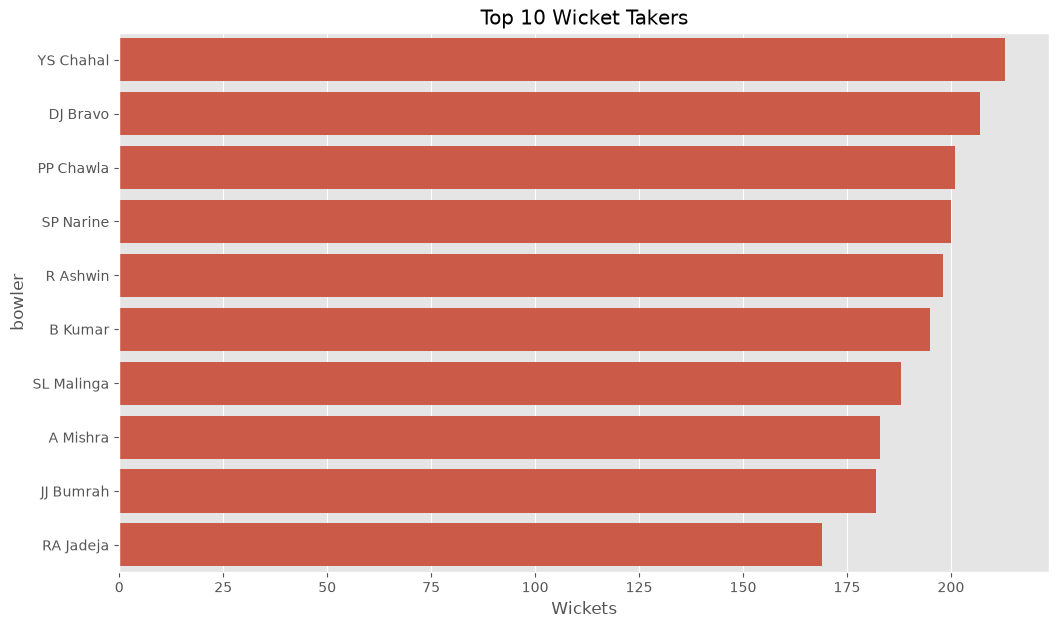

In [9]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=purple_cap.head(10),
    x="Wickets",
    y="bowler"
)

plt.title("Top 10 Wicket Takers")

plt.show()

In [10]:
powerplay = deliveries[
    deliveries["over"] <= 6
]

powerplay_runs = (
    powerplay.groupby("batter")["batsman_runs"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(powerplay_runs.head(15))

,batter,batsman_runs
0,S Dhawan,3776
1,DA Warner,3648
2,V Kohli,3178
3,CH Gayle,2668
4,AM Rahane,2567
5,G Gambhir,2539
6,RG Sharma,2437
7,F du Plessis,2361
8,RV Uthappa,2353
9,KL Rahul,2260


In [11]:
death = deliveries[
    deliveries["over"] >= 16
]

death_runs = (
    death.groupby("batter")["batsman_runs"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(death_runs.head(15))

,batter,batsman_runs
0,MS Dhoni,2786
1,KA Pollard,1708
2,KD Karthik,1565
3,AB de Villiers,1421
4,RA Jadeja,1420
5,RG Sharma,1176
6,HH Pandya,1126
7,V Kohli,1099
8,AD Russell,1065
9,DA Miller,988


In [12]:
venue_wins = (
    matches.groupby(["venue","winner"])
    .size()
    .reset_index(name="Wins")
)

display(venue_wins.head(20))

,venue,winner,Wins
0,Arun Jaitley Stadium,Chennai Super Kings,1
1,Arun Jaitley Stadium,Delhi Capitals,8
2,Arun Jaitley Stadium,Mumbai Indians,1
3,Arun Jaitley Stadium,Punjab Kings,1
4,Arun Jaitley Stadium,Royal Challengers Bengaluru,1
5,Arun Jaitley Stadium,Sunrisers Hyderabad,2
6,"Arun Jaitley Stadium, Delhi",Chennai Super Kings,2
7,"Arun Jaitley Stadium, Delhi",Delhi Capitals,6
8,"Arun Jaitley Stadium, Delhi",Gujarat Titans,1
9,"Arun Jaitley Stadium, Delhi",Mumbai Indians,3


In [13]:
orange_cap.to_csv("../data/processed/orange_cap.csv",index=False)

purple_cap.to_csv("../data/processed/purple_cap.csv",index=False)

head_to_head.to_csv("../data/processed/head_to_head.csv",index=False)

print("Advanced Analysis Saved Successfully!")

Advanced Analysis Saved Successfully!
